In [2]:
import pandas as pd
#importing all relevant files :)
subjectnr=4
groupNr=subjectnr %8+1

path="../../01_experiment/recordings/validParticipants/"
path_info="../../01_experiment/stimuli/creatingDataStructure/participant_groups_8/participant_group"+str(groupNr)+".csv"
part_df_tmp=pd.read_csv(path+"subject-"+str(subjectnr)+".csv")
gazeSamples_df=pd.read_table(path+"subject-"+str(subjectnr)+".tsv")
gazeSamples_df_reduced=gazeSamples_df[["TIME","BPOGX","BPOGY","BPOGV","USER"]]
gazeSamples_df.columns

group_df=pd.read_csv(path_info)

annotationPath="../../01_experiment/stimuli/annotation_audiov2.csv"
annotation_df=pd.read_csv(annotationPath)

annotation_df




,id,word,SentenceRole,WordRole,start,end,sentence
0,0,The,restrictive,det,0.021,0.063,The boy will eat the cake
1,0,boy,restrictive,nsubj,0.147,0.420,The boy will eat the cake
2,0,will,restrictive,aux,0.546,0.672,The boy will eat the cake
3,0,eat,restrictive,ROOT,0.819,0.945,The boy will eat the cake
4,0,the,restrictive,det,1.050,1.113,The boy will eat the cake
...,...,...,...,...,...,...,...
600,49,will,non-restrictive,aux,0.588,0.714,The man will pick up the stamp
601,49,pick,non-restrictive,ROOT,0.798,1.029,The man will pick up the stamp
602,49,up,non-restrictive,prt,1.155,1.239,The man will pick up the stamp
603,49,the,non-restrictive,det,1.323,1.386,The man will pick up the stamp


In [3]:
part_df=part_df_tmp[["id","position1","position2","position3","position4","count_audio_file_offset","audio_file","condition"]]
part_df.rename(columns={'count_audio_file_offset': 'trialID'}, inplace=True)
part_df.rename(columns={'id': 'stimuliID'}, inplace=True)
part_df

,stimuliID,position1,position2,position3,position4,trialID,audio_file,condition
0,16,backpack,ribbon,dress,lantern,0,16_r.wav,restrictive
1,27,picture,lamp,switch,frame,1,27_n.wav,non-restrictive
2,12,sun,car,boat,birds,2,12_r.wav,restrictive
3,0,toy-train,ball,cake,toy-car,3,0_r.wav,restrictive
4,41,stone,cone,shell,orange,4,41_n.wav,non-restrictive
5,10,washing-machine,mirror,dog,wastebin,5,10_r.wav,restrictive
6,38,apron,mop,broom,cloth,6,38_r.wav,restrictive
7,45,laddle,peeler,pot,carrot,7,45_n.wav,non-restrictive
8,30,dice,cap,watch,headphones,8,30_r.wav,restrictive
9,23,card,scarf,pencil,needle,9,23_n.wav,non-restrictive


In [4]:
#filter invalid samples based on BPOGV (if BPOGV is false not bnoth eyes have been detected.)
#maybe we should introduce cutpoff for trials where only a low number of gaze samples are valid...?

#samples_valid = gazeSamples_df_reduced[gazeSamples_df_reduced["BPOGV"] != 0]
#samples_valid

In [5]:
#before we continue we should add trial numbers to the gaze samples starting with 1
#the construct of this cell was created with gpt:
is_start = gazeSamples_df_reduced["USER"].eq("START_TRIAL")
is_stop = gazeSamples_df_reduced["USER"].eq("STOP_TRIAL")

inside = False
current_id = -1
ids = []

for start, stop in zip(is_start, is_stop):
    if start:
        inside = True
        current_id += 1
    #using str here to make merging easier later
    ids.append(str(current_id) if inside else None)

    if stop:
        inside = False

gazeSamples_df_reduced["trialId"] = ids

# Alles außerhalb eines Intervalls entfernen
samples_onlyTrials = gazeSamples_df_reduced[gazeSamples_df_reduced["trialId"].notna()]
samples_onlyTrials


#sanity checking: correct :) all ids are moving up in correct range
#svd=samples_valid_onlyTrials[samples_valid_onlyTrials["USER"]=="START_TRIAL"]
#svd=samples_valid_onlyTrials[samples_valid_onlyTrials["USER"]=="STOP_TRIAL"]

,TIME,BPOGX,BPOGY,BPOGV,USER,trialId
1,539.16956,0.41481,0.46420,1,START_TRIAL,0
2,539.17627,0.42074,0.49426,1,NaN,0
3,539.18256,0.44048,0.47778,1,NaN,0
4,539.18939,0.44026,0.47720,1,NaN,0
5,539.19623,0.46112,0.51355,1,NaN,0
...,...,...,...,...,...,...
47273,936.47699,0.35319,0.64224,1,NaN,49
47274,936.48364,0.35281,0.63988,1,NaN,49
47275,936.49017,0.35843,0.62136,1,NaN,49
47276,936.49664,0.36568,0.65113,1,NaN,49


NameError: name 'img' is not defined

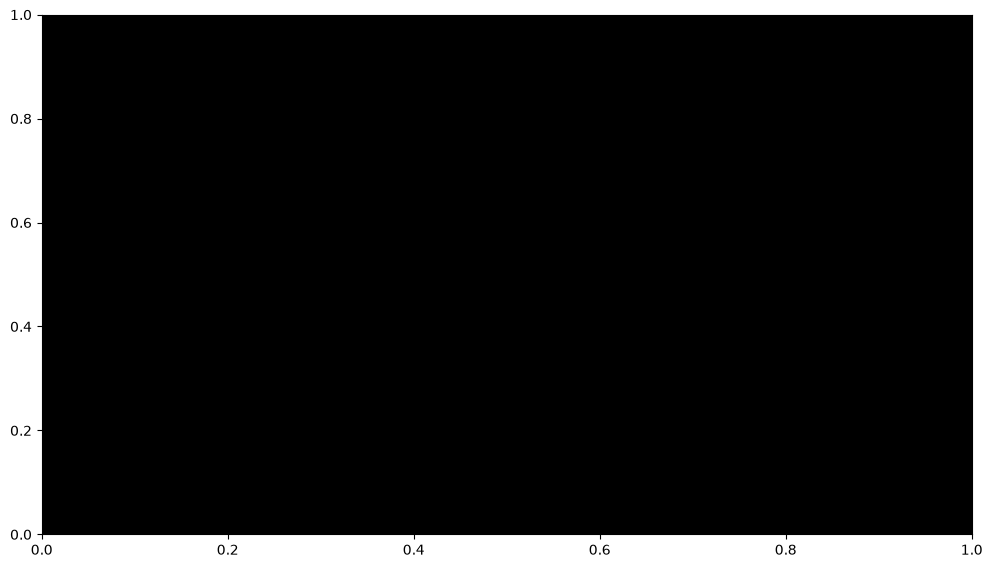

In [6]:
#the AOIs for the 4 objects have these positions in image coords (top left aligned just as open gaze as well):
#AOIS have size of 400x400
positions_old = {
    "pos1": (1782, 378),
    "pos2": (1342, 825),
    "pos3": (657, 825),
    "pos4": (217, 378),
}
#________________________________________
#we have to use scaled positions though as we displayed a 2400x1400 image on 1920x1080 screen.
positions = {
    "pos1": (1745.6, 462.4),
    "pos2": (1393.6, 820.0),
    "pos3": (845.6,  820.0),
    "pos4": (493.6,  462.4),
}

#also scaled these so they are not sqares anymore actually...need to take care of rsolution better next time !
box_width = 320
box_height = 309
#________________________________________

#also it seems the screen resolution was at 1920x1080, if i read it coirrectly fromm the logfile. so we should change this for the real trials!
#for now we need to convert image coords to screen coords that we have in open gaze. 



#additional sanity check //outline created with claude:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np
from matplotlib.patches import Rectangle

# ── Config — adjust these ──────────────────────────────────────────
#SCREEN_W, SCREEN_H = 1920, 1080
IMG_PATH = "../../01_experiment/stimuli/img_composition/1_pos1_nosub.png"   # the actual displayed canvas image
SCREEN_W, SCREEN_H = 2560, 1440  # OpenSesame virtual canvas
IMG_W, IMG_H = 2400, 1400        # from your image

SCALE = 0.8  # explicitly set in OpenSesame sketchpad

disp_w = IMG_W * SCALE    # 1920.0
disp_h = IMG_H * SCALE    # 1120.0
offset_x = (SCREEN_W - disp_w) / 2  # 320.0
offset_y = (SCREEN_H - disp_h) / 2  # 160.0

# ── Convert gaze samples: normalized -> screen pixels ──────────────
valid = samples_onlyTrials[samples_onlyTrials["BPOGV"] == 1].copy()
valid["screen_x"] = valid["BPOGX"] * SCREEN_W
valid["screen_y"] = valid["BPOGY"] * SCREEN_H

# ── Plot: full screen canvas, image placed at its real position, gaze on top
fig, ax = plt.subplots(figsize=(12, 6.75))  # matches 16:9 aspect

# black screen background
ax.add_patch(patches.Rectangle((0, 0), SCREEN_W, SCREEN_H, color="black", zorder=0))

# image placed at its actual displayed position/size
ax.imshow(img, extent=[offset_x, offset_x + disp_w, offset_y + disp_h, offset_y], zorder=1)
# note: extent y is [top, bottom] reversed because imshow origin is upper-left by default

# gaze samples on top
ax.scatter(valid["screen_x"], valid["screen_y"], s=10, c="red", alpha=0.5, zorder=2, label="gaze samples")

for name, (x, y) in positions.items():
    rect = Rectangle(
        (x, y),            # top-left corner
        box_width,         # width
        box_height,        # height
        linewidth=3,
        edgecolor='blue',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.set_xlim(0, SCREEN_W)
ax.set_ylim(SCREEN_H, 0)  # y-axis flipped so (0,0) is top-left, matching screen coords
ax.set_aspect("equal")
ax.set_title(f"{len(valid)} valid gaze samples on screen ({SCREEN_W}x{SCREEN_H})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [ ]:
#we also want to filter all samples and only keep those that are in the relevant time frame for each trial.
#this is inbeteween VERB ONSET ( called root start) and TARGET OBJECT ONSET (called dobj start)
#we can reference annotation_audiov2.csv for this.

In [36]:
#for this we cretae a helper dataframe that saves a collection of all audio offset recordings for each trial:
onsetsetsAudioFiles=samples_onlyTrials[samples_onlyTrials["USER"]=="AUDIO_FILE_ONSET_LOG"]
onsetsetsAudioFiles.rename(columns={"TIME":"audio_onset_time"},inplace=True)
onsetsetsAudioFiles=onsetsetsAudioFiles[["audio_onset_time","trialId"]]

onsetsetsAudioFiles

,audio_onset_time,trialId
606,543.22205,0
1465,551.99023,1
2297,560.57068,2
3140,568.23328,3
4014,575.10590,4
4891,581.99170,5
5954,591.12823,6
6827,599.98328,7
7808,607.57214,8
8679,615.41608,9


In [8]:

#helper function to retrive timestamps for specific stimulinr, restr/notrestrictive

def getTS(stimulus_id, restrictive):
    df=annotation_df[annotation_df["id"]==stimulus_id]
    if restrictive:
        df_=df[df["SentenceRole"]=="restrictive"]
    else:
        df_=df[df["SentenceRole"]=="non-restrictive"]
        #for us the start of verb and start of target noun are relevant

    df_single_verb=df_[df_["WordRole"]=="ROOT"]
    df_single_noun=df_[df_["WordRole"]=="dobj"]

    #check if really only a single word was filtered
    assert len(df_single_verb) == 1, "Expected one root verb"
    assert len(df_single_noun) == 1, "Expected one direct object noun"

    startVerb = df_single_verb["start"].values[0]
    startNoun = df_single_noun["start"].values[0]
    return startVerb, startNoun

#sanity check: for time frame in sentence one restrictive version:
#print(getTS(0, True))

In [9]:
annotation_df.rename(columns={"id":"stimuliID"},inplace=True)
annotation_df.rename(columns={"SentenceRole":"condition"},inplace=True)
#part_df=part_df.merge(annotation_df,on=["stimuliID","condition"])
annotation_df

,stimuliID,word,condition,WordRole,start,end,sentence
0,0,The,restrictive,det,0.021,0.063,The boy will eat the cake
1,0,boy,restrictive,nsubj,0.147,0.420,The boy will eat the cake
2,0,will,restrictive,aux,0.546,0.672,The boy will eat the cake
3,0,eat,restrictive,ROOT,0.819,0.945,The boy will eat the cake
4,0,the,restrictive,det,1.050,1.113,The boy will eat the cake
...,...,...,...,...,...,...,...
600,49,will,non-restrictive,aux,0.588,0.714,The man will pick up the stamp
601,49,pick,non-restrictive,ROOT,0.798,1.029,The man will pick up the stamp
602,49,up,non-restrictive,prt,1.155,1.239,The man will pick up the stamp
603,49,the,non-restrictive,det,1.323,1.386,The man will pick up the stamp


In [56]:
#now we use a function to clauculate a list of dictionaries (objects)->percentages per target :)

for trialNr in range(0,50):

    #first we get all dataframes of one trial
    #print(trialNr)
    trial_info=part_df[part_df["trialID"]==trialNr]
    stimuliID=trial_info["stimuliID"].values[0]
    condition=trial_info["condition"].values[0]
    
    audioStart_trial=onsetsetsAudioFiles[onsetsetsAudioFiles["trialId"]==str(trialNr)]["audio_onset_time"].values[0]

    #position mappings:

    #start and ending time:
    trial_annotation_df=annotation_df[annotation_df["stimuliID"]==stimuliID]
    trial_annotation_df=trial_annotation_df[trial_annotation_df["condition"]==condition]
    #verb
    verbOnset=trial_annotation_df[trial_annotation_df["WordRole"]=="ROOT"]["start"].values[0]
    #object
    try:
        #here we found an error because w e only used dobj as role for the target objectz but üobj can also occur (actually only once)
        objectOnset=trial_annotation_df[(trial_annotation_df["WordRole"]=="dobj") | (trial_annotation_df["WordRole"]=="pobj")]["start"].values[0]
    except:
        print("error on"+str(stimuliID))
    
    
    #petting audio intervall in seconds
    start=audioStart_trial+verbOnset
    stop=audioStart_trial+objectOnset

    #restrict interval
    samples_restricted=samples_onlyTrials[(start<samples_onlyTrials["TIME"])&(samples_onlyTrials["TIME"]<stop)]

samples_restricted

,TIME,BPOGX,BPOGY,BPOGV,USER,trialId
47030,934.84900,0.48847,0.08363,1,NaN,49
47031,934.85602,0.48867,0.08813,1,NaN,49
47032,934.86267,0.49909,0.08329,1,NaN,49
47033,934.86902,0.49485,0.07259,1,NaN,49
47034,934.87604,0.49456,0.07212,1,NaN,49
...,...,...,...,...,...,...
47100,935.31812,0.40567,0.62832,1,NaN,49
47101,935.32495,0.40287,0.64624,1,NaN,49
47102,935.33130,0.41152,0.67884,1,NaN,49
47103,935.33777,0.41138,0.67674,1,NaN,49
